# AKI Calculation - Gather Covariates and Recreate Model (Notebook 4 of 4) 

## Description

These notebooks are our first attempt to identify the subjects with AKI in our cohort, based on the KDIGO SCr criteria.

The code to calculate AKI within the VPS-PN cohort can be found here: https://github.com/Lab-for-Integrated-Decision-Support/vps-peds-mods. The relevant code and folders are:

The general process of this notebook is as follows:

- Gather covariates - recall that for the original model, this includes "cardiac arrest pre-admission" which we will have to get from diagnoses codes, and "post-operative" which we likely cannot include.
- Calculate AKI risk based on the Sanchez-Pinto 2016 coefficients on the covariates
  - Generate an ROC curve based on this score and report the AUROC
  - Calculate the thresholds at 50% and 90% and report results

### Initialize and Load Functions

First we set the folder path, and define the function `load_data_file` to load the specific PDC data file from this folder.

In [1]:
import pandas as pd
import numpy
import os, sys, importlib 

import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

try:
    import pyspark
    import pyspark.pandas as ps
except:
    %pip install pyspark
    import pyspark
    import pyspark.pandas as ps

try:
    import plotly.express as px
except:
    %pip install plotly
    import plotly.express as px

import azure_BlobStorageConnection
import load_utils

Set environment variables using script.

In [2]:
from set_env_vars import set_all_env_vars

set_all_env_vars()

Add global debug_ variables to determine when to print out counts, show data tables, and plot graphs. This speeds processing in the PySpark environment, but may not matter if we're working solely with pandas data frames.

In [3]:
debug_count = True
debug_show = True
debug_plot = True

Add variable `save_figs` to indicate whether produced figures should be saved.

In [4]:
save_figs = True

if not os.path.isdir('visualizations'):
    os.mkdir('visualizations')

Load necessary data files.

In [7]:
import azureml.fsspec

DATASTORE_PATH = '...'

uri = DATASTORE_PATH + 'pdc_ci_westus_research_readwrite_iam_link/paths/meds-wg/'

labs_lim = pd.read_csv(
    uri + 'labs.csv', 
    usecols=["pdc_hid", "pdc_pid", "resulttime", "pdc_name", "source_units", "source_value"]
)

In [8]:
base_cohort = pd.read_csv(os.environ['AKI_DATA_PDC'] + 'base_cohort_v2.csv')

final_aki_cohort = pd.read_csv(os.environ['AKI_DATA_PDC'] + 'final_aki_cohort.csv')

### Gather Covariates

Now that we have the output defined, we gather the covariates necessary to run the prediction model. The labs we need are:

- Post-operative recovery
- Pre-admission cardiac arrest
- BUN (mg/dL) as [BUN]
- pH as [PH_ART, PH_CAP, PH_VEN]
- Platelet count (K/uL) as [PLTS]
- Total bilirubin (mg/dL) as [BILIRUBIN_TOT]
- Age (yrs)

#### Labs

First we write a function which will pull labs based on a list of lab aliases:

In [9]:
for col in labs_lim.columns:
    print(col)

pdc_pid
pdc_hid
pdc_name
resulttime
source_value
source_units


In [10]:
def get_labs(lab_list, labs_lim, base_cohort, debug_count, debug_show):
    """
    Gather labs of a certain PDC type
    """
    
    # Filter the labs to the types of interest
    labs_res = labs_lim[labs_lim['pdc_name'].isin(lab_list)]
    
    # Convert necessary columns to numbers
    get_numeric = lambda val: float(val) if (val and str(val).replace('.', '').isdigit()) else numpy.nan
    labs_res['val_numeric'] = [get_numeric(val) for val in labs_res['source_value']]
    # labs_res['val_numeric'] = labs_res['source_value'].astype(float)
    labs_res['n_res_time'] = labs_res['resulttime'].astype('long')
    labs_res.drop_duplicates(inplace=True)
    
    if debug_count: print('Number of rows of all values for lab types passed in: %d' % len(labs_res))
    
    # Join to base cohort
    labs_res_join = base_cohort.merge(
        labs_res,
        on=['pdc_hid', 'pdc_pid'],
        how='left'
    ) \
    .drop_duplicates()
    if debug_count: print('Number of rows in left join: %d' % len(labs_res_join))
    
    # Filter to include only those with the time in between the ICU admission and +12 hours
    labs_res_join['result_after_admit'] = [1 if gte else 0 for gte in (labs_res_join['n_res_time'] >= labs_res_join['n_icuadmit'])]
    labs_res_join['12hrs_after_admit'] = [n_admit + 12*60*60 for n_admit in labs_res_join['n_icuadmit']]
    labs_res_join['result_lte_12hrs_after_admit'] = [1 if lte else 0 for lte in (labs_res_join['n_res_time'] <= labs_res_join['12hrs_after_admit'])]
    labs_res_join['keep_lab'] = labs_res_join['result_after_admit'] * labs_res_join['result_lte_12hrs_after_admit']
    labs_res_join_filter = labs_res_join[labs_res_join['keep_lab'] == 1]
    # labs_res_join_filter = labs_res_join[
    #     (labs_res_join['n_res_time'] >= labs_res_join['n_icuadmit']) and (labs_res_join['n_res_time'] <= [n_admit + 12*60 for n_admit in labs_res_join['n_icuadmit']])
    # ]
    if debug_count: print('Number of filtered rows in ICU-only dataset: %d' % len(labs_res_join_filter))
    
    if debug_show: display(labs_res_join_filter.head())
    
    return labs_res_join_filter

Now we apply that function to pull labs:

In [11]:
# pH Values
ph_res = get_labs(
    ['PH_ART', 'PH_VEN', 'PH_CAP'],
    labs_lim,
    base_cohort,
    debug_count,
    debug_show
)
print('Gathered pH values.')

# Blood Urea Nitrogen Values
bun_res = get_labs(
    ['BUN'],
    labs_lim,
    base_cohort,
    debug_count,
    debug_show
)
print('Gathered blood urea nitrogen values.')

# Platelet Count Values
plt_res = get_labs(
    ['PLTS'],
    labs_lim,
    base_cohort,
    debug_count,
    debug_show
)
print('Gathered platelet count values.')

# Bilirubin Values
bili_res = get_labs(
    ['BILIRUBIN_TOT'],
    labs_lim,
    base_cohort,
    debug_count,
    debug_show
)
print('Gathered bilirubin values.')

Number of rows of all values for lab types passed in: 1508028
Number of rows in left join: 2258597
Number of filtered rows in ICU-only dataset: 175376


,pdc_eid,pdc_hid,icumedicaldischarge,icuadmission,icumortality,icudischarge,site_id,pdc_pid,sex,ageatadmission,...,pdc_name,resulttime,source_value,source_units,val_numeric,n_res_time,result_after_admit,12hrs_after_admit,result_lte_12hrs_after_admit,keep_lab
0,104033001,104171001,81000.0,1800,0.0,84480.0,1,102005001,Male,4689,...,PH_CAP,25500.0,7.33,Unit,7.33,25500.0,1,45000,1,1
2,104033001,104171001,81000.0,1800,0.0,84480.0,1,102005001,Male,4689,...,PH_VEN,23040.0,7.31,Unit,7.31,23040.0,1,45000,1,1
3,104033001,104171001,81000.0,1800,0.0,84480.0,1,102005001,Male,4689,...,PH_VEN,42360.0,7.31,Unit,7.31,42360.0,1,45000,1,1
5,104035001,103775001,71880.0,180,0.0,81540.0,1,102644001,Male,6562,...,PH_CAP,6420.0,7.34,Unit,7.34,6420.0,1,43380,1,1
8,104037001,102745001,63660.0,1560,0.0,77160.0,1,101967001,Female,6089,...,PH_ART,6360.0,6.91,Unit,6.91,6360.0,1,44760,1,1


Gathered pH values.
Number of rows of all values for lab types passed in: 1190292
Number of rows in left join: 1599902
Number of filtered rows in ICU-only dataset: 100348


,pdc_eid,pdc_hid,icumedicaldischarge,icuadmission,icumortality,icudischarge,site_id,pdc_pid,sex,ageatadmission,...,pdc_name,resulttime,source_value,source_units,val_numeric,n_res_time,result_after_admit,12hrs_after_admit,result_lte_12hrs_after_admit,keep_lab
1,104033001,104171001,81000.0,1800,0.0,84480.0,1,102005001,Male,4689,...,BUN,23040.0,6,mg/dL,6.0,23040.0,1,45000,1,1
5,104037001,102745001,63660.0,1560,0.0,77160.0,1,101967001,Female,6089,...,BUN,6660.0,14,mg/dL,14.0,6660.0,1,44760,1,1
6,104037001,102745001,63660.0,1560,0.0,77160.0,1,101967001,Female,6089,...,BUN,14160.0,13,mg/dL,13.0,14160.0,1,44760,1,1
7,104037001,102745001,63660.0,1560,0.0,77160.0,1,101967001,Female,6089,...,BUN,24060.0,12,mg/dL,12.0,24060.0,1,44760,1,1
8,104037001,102745001,63660.0,1560,0.0,77160.0,1,101967001,Female,6089,...,BUN,35460.0,11,mg/dL,11.0,35460.0,1,44760,1,1


Gathered blood urea nitrogen values.
Number of rows of all values for lab types passed in: 1004877
Number of rows in left join: 1424584
Number of filtered rows in ICU-only dataset: 96409


,pdc_eid,pdc_hid,icumedicaldischarge,icuadmission,icumortality,icudischarge,site_id,pdc_pid,sex,ageatadmission,...,pdc_name,resulttime,source_value,source_units,val_numeric,n_res_time,result_after_admit,12hrs_after_admit,result_lte_12hrs_after_admit,keep_lab
1,104033001,104171001,81000.0,1800,0.0,84480.0,1,102005001,Male,4689,...,PLTS,23040.0,304,K/uL,304.0,23040.0,1,45000,1,1
5,104037001,102745001,63660.0,1560,0.0,77160.0,1,101967001,Female,6089,...,PLTS,43260.0,291,K/uL,291.0,43260.0,1,44760,1,1
7,104038001,106863001,416400.0,17580,0.0,422100.0,1,105275001,Female,1371,...,PLTS,18300.0,147,K/uL,147.0,18300.0,1,60780,1,1
8,104038001,106863001,416400.0,17580,0.0,422100.0,1,105275001,Female,1371,...,PLTS,33480.0,122,K/uL,122.0,33480.0,1,60780,1,1
9,104038001,106863001,416400.0,17580,0.0,422100.0,1,105275001,Female,1371,...,PLTS,46140.0,135,K/uL,135.0,46140.0,1,60780,1,1


Gathered platelet count values.
Number of rows of all values for lab types passed in: 395932
Number of rows in left join: 580741
Number of filtered rows in ICU-only dataset: 35096


,pdc_eid,pdc_hid,icumedicaldischarge,icuadmission,icumortality,icudischarge,site_id,pdc_pid,sex,ageatadmission,...,pdc_name,resulttime,source_value,source_units,val_numeric,n_res_time,result_after_admit,12hrs_after_admit,result_lte_12hrs_after_admit,keep_lab
5,104038001,106863001,416400.0,17580,0.0,422100.0,1,105275001,Female,1371,...,BILIRUBIN_TOT,46140.0,2.6,mg/dL,2.6,46140.0,1,60780,1,1
6,104038001,106863001,416400.0,17580,0.0,422100.0,1,105275001,Female,1371,...,BILIRUBIN_TOT,47220.0,0.8,mg/dL,0.8,47220.0,1,60780,1,1
9,104039001,103586001,156900.0,2100,0.0,250800.0,1,105277001,Male,1213,...,BILIRUBIN_TOT,20400.0,0.3,mg/dL,0.3,20400.0,1,45300,1,1
35,104045001,105269001,47460.0,660,0.0,70020.0,1,101444001,Male,5660,...,BILIRUBIN_TOT,34860.0,0.6,mg/dL,0.6,34860.0,1,43860,1,1
52,104050001,104610001,8474100.0,9840,1.0,8497860.0,1,101324001,Female,89,...,BILIRUBIN_TOT,11040.0,0.2,mg/dL,0.2,11040.0,1,53040,1,1


Gathered bilirubin values.


To ensure that we don't have unit discrepencies, we write a function to summarize the values (using https://stackoverflow.com/questions/33575587/pandas-dataframe-how-to-apply-describe-to-each-group-and-add-to-new-columns as reference for group_summarize() function):

In [12]:
def group_summarize(source_df, group_var, sum_var):
    """
    Summarize a dataframe by a grouping variable.
    """
    
    df = source_df.groupby(group_var).describe()#.unstack(1)
    
    display(df)
    
def report_src_units(source_df):
    """
    Generate a table of counts by site and source units
    """
    
    df = source_df.rename(columns={'pdc_pid': 'count'})[[
        'site_id',
        'source_units',
        'count'
    ]] \
    .groupby(['site_id', 'source_units']) \
    .count() \
    .reset_index() \
    .sort_values(['site_id', 'source_units'])
    
    display(df)

And we apply those functions on the above-extracted data frames:

In [13]:
if debug_count:
    print('pH')
    group_summarize(ph_res[['val_numeric', 'site_id']], 'site_id', 'val_numeric')
    print('\nbun')
    group_summarize(bun_res[['val_numeric', 'site_id']], 'site_id', 'val_numeric')
    print('\nplt')
    group_summarize(plt_res[['val_numeric', 'site_id']], 'site_id', 'val_numeric')
    print('\nbili')
    group_summarize(bili_res[['val_numeric', 'site_id']], 'site_id', 'val_numeric')

pH


val_numeric                                                       
              count      mean       std    min    25%    50%    75%    max
site_id                                                                   
1           13727.0  7.349156  0.093071  6.580  7.310  7.360  7.400  7.850
3           33335.0  7.332223  0.105797  6.510  7.290  7.350  7.390  7.710
4           10998.0  7.305265  0.117444  6.730  7.250  7.320  7.380  7.740
5           23987.0  7.349418  0.088828  6.800  7.310  7.360  7.400  7.690
6           26668.0  7.304789  0.116391  6.560  7.250  7.320  7.380  7.750
8           19479.0  7.342249  0.098067  6.434  7.294  7.355  7.405  7.715
9           46582.0  7.328752  0.103225  6.510  7.280  7.340  7.390  8.130


bun


val_numeric                                                   
              count       mean        std  min  25%   50%   75%    max
site_id                                                               
1            7235.0  14.822668  14.506229  2.0  8.0  11.0  16.0  212.0
3           12135.0  16.759456  15.359595  4.0  9.0  13.0  19.0  240.0
4            8446.0  14.612681  13.577372  1.0  8.0  11.0  16.0  194.0
5            9675.0  13.937674  12.219968  2.0  8.0  11.0  16.0  240.0
6           21311.0  15.334710  16.762894  1.6  8.0  11.0  16.0  251.0
8           21479.0  14.570511  15.842628  2.0  7.0  10.0  15.0  250.0
9           18426.0  14.205688  13.245423  1.0  8.0  11.0  16.0  201.0


plt


val_numeric                                                          
              count        mean         std  min    25%    50%    75%     max
site_id                                                                      
1            6371.0  214.254277  109.085799  5.0  144.0  204.0  272.0   938.0
3           14410.0  229.048647  128.183082  5.0  144.0  216.0  296.0  1381.0
4            5994.0  248.782282  131.029042  1.0  162.0  233.0  316.0  1269.0
5            6716.0  232.247022  127.723218  1.0  144.0  215.0  298.0  1520.0
6           13113.0  228.455807  135.030961  1.0  134.0  219.0  302.0  2264.0
8           18400.0  222.008810  140.754224  0.0  117.0  211.0  298.0  1497.6
9           18530.0  237.748462  124.113870  2.0  158.0  224.0  298.0  1099.0


bili


val_numeric                                                   
              count      mean       std  min  25%   50%     75%    max
site_id                                                               
1            3456.0  1.894453  2.903502  0.1  0.4  0.78  1.8925  31.65
3            1113.0  5.233783  4.884759  0.0  1.8  4.00  7.6000  60.10
4            2734.0  1.215947  2.386835  0.0  0.3  0.50  1.0000  44.40
5            2580.0  1.767093  2.978505  0.1  0.3  0.50  1.5250  45.10
6            5164.0  1.364040  2.629076  0.1  0.3  0.60  1.1000  38.30
8            7299.0  1.463666  3.124355  0.0  0.4  0.60  1.2000  45.90
9           11186.0  3.646344  5.327670  0.1  0.5  1.40  3.8000  49.60

In [14]:
if debug_count:
    print('pH')
    report_src_units(ph_res)
    print('bun')
    report_src_units(bun_res)
    print('plt')
    report_src_units(plt_res)
    print('bili')
    report_src_units(bili_res)

pH


,site_id,source_units,count
0,1,Unit,13790
1,4,pH,11010


bun


,site_id,source_units,count
0,1,mg/dL,7323
1,3,mg/dL,12834
2,4,mg/dL,8465
3,5,mg/dL,9935
4,6,MG/DL,11726
5,6,mg/dL,9844
6,8,mg/dL,4230


plt


,site_id,source_units,count
0,1,K/uL,6407
1,3,K/mm3,14516
2,4,K/uL,6012
3,5,THOU/uL,7003
4,6,10 3/uL,13558
5,8,10*3/uL,3552


bili


,site_id,source_units,count
0,1,mg/dL,3500
1,3,mg/dL,1121
2,4,mg/dL,3098
3,5,mg/dL,3098
4,6,MG/DL,3059
5,6,mg/dL,2299
6,6,mg/dl,1
7,8,mg/dL,1477
8,9,mg/dL,1115


#### Cardiac Arrest Diagnoses

Now we have to pull the cardiac arrest diagnoses. We begin by loading the diagnoses file (`conditionsprocs`). We then scan the conditions for codes which match cardiac arrest codes.

In [19]:
# diags_df = load_utils.load_data_file(file = 'conditionsprocs', blob_datastore = d_s, path = '8-site-pandas/', debug = debug_count)

import azureml.fsspec

uri = 'azureml://subscriptions/b06a3f28-16e7-4bcd-ab95-f192daca58db/resourcegroups/pdc-rg-westus-research/workspaces/pdc-mlw-westus-research1/datastores/pdc_ci_westus_research_readwrite_iam_link/paths/meds-wg/'

diags_df = pd.read_csv(
    uri + 'conditionsprocs.csv',
    on_bad_lines='skip'
)

The cell below is the one where we search for cardiac arrest and summarize those codes below:

In [20]:
diags_df['lower_text'] = [text.lower() for text in diags_df['codetext']]

diags_df = diags_df[diags_df['lower_text'].str.contains('cardiac arrest')]

Now we identify encounters which had one of these codes present:

In [21]:
code_list = ['I46.9', 'I46.8', 'I462', 'I469', 'I468', '427.5', 'I46.2']

ca_diags = diags_df[diags_df['code'].isin(code_list)][[
    'pdc_hid', 
    'site_id'
]].drop_duplicates()

ca_diags['cardiac_arrest'] = [1 for i in range(len(ca_diags))]

if debug_count: print('Number of rows in the cardiac arrest diagnoses dataframe: %d' % len(ca_diags))

if debug_show: ca_diags.head()

Number of rows in the cardiac arrest diagnoses dataframe: 2943


## Generate model

Now that we have all of the covariates we can identify, we bring them together in a dataframe to be used for the creation of the AKI prediction model.

<Axes: xlabel='site_id', ylabel='age_admit_yrs'>

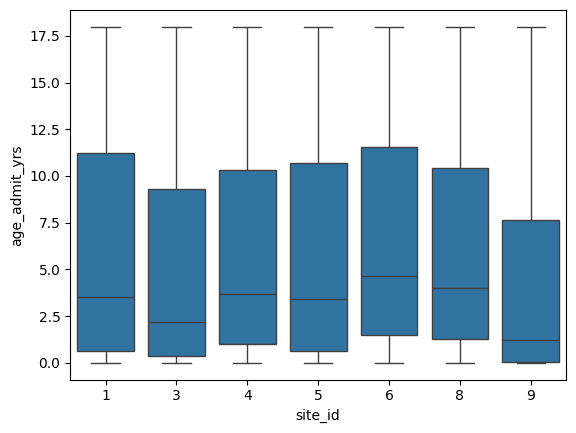

In [22]:


sns.boxplot(
    final_aki_cohort,
    y='age_admit_yrs',
    x='site_id'
)

In [23]:
cohort_w_covar = final_aki_cohort.copy()

cohort_w_covar['coeff_age'] = cohort_w_covar['age_admit_yrs'] * 0.02

"""
Prepare dataframes for each lab type and join to cohort
"""

# pH
# Ranges:
# x < 7.21
# x >= 7.21

min_pH = ph_res[[
    'pdc_hid', 
    'pdc_eid', 
    'val_numeric'
]] \
.groupby(['pdc_hid', 'pdc_eid']) \
.min() \
.reset_index() \
.rename(columns = {'val_numeric': 'min_ph'})

cohort_w_covar = cohort_w_covar.merge(
    min_pH,
    on=['pdc_hid', 'pdc_eid'],
    how='left'
)
cohort_w_covar['min_ph_is_na'] = cohort_w_covar['min_ph'].isna()
cohort_w_covar['min_ph'].fillna(7.4, inplace=True)
cohort_w_covar['coeff_ph'] = numpy.where(
    cohort_w_covar['min_ph'] < 7.21,
    1.04, # if true
    0     # else
)

# Blood Urea Nitrogen
# Ranges:
# x < 15
# 15 <= x < 25
# x >= 25

max_bun = bun_res[[
    'pdc_hid',
    'pdc_eid',
    'val_numeric'
]] \
.groupby(['pdc_hid', 'pdc_eid']) \
.max() \
.reset_index() \
.rename(columns = {'val_numeric': 'max_bun'})

cohort_w_covar = cohort_w_covar.merge(
    max_bun,
    on=['pdc_hid', 'pdc_eid'],
    how='left'
)
cohort_w_covar['max_bun_is_na'] = cohort_w_covar['max_bun'].isna()
cohort_w_covar['max_bun'].fillna(0, inplace=True)
cohort_w_covar['coeff_bun'] = numpy.where(
    cohort_w_covar['max_bun'] < 15,
    0, # bun < 15
    numpy.where(
        cohort_w_covar['max_bun'] < 25,
        0.73, # 15 <= bun < 25
        2.02 # 25 <= bun
    )
)

# Platelet Count
# Ranges:
# x < 50
# 50 <= x < 95
# 95 <= x < 175
# x >= 175

min_plt = plt_res[[
    'pdc_hid',
    'pdc_eid',
    'val_numeric'
]] \
.groupby(['pdc_hid', 'pdc_eid']) \
.min() \
.reset_index() \
.rename(columns = {'val_numeric': 'min_plt'})

cohort_w_covar = cohort_w_covar.merge(
    min_plt,
    on=['pdc_hid', 'pdc_eid'],
    how='left'
)
cohort_w_covar['min_plt_is_na'] = cohort_w_covar['min_plt'].isna()
cohort_w_covar['min_plt'].fillna(200, inplace=True)
cohort_w_covar['coeff_plt'] = numpy.where(
    cohort_w_covar['min_plt'] < 50,
    1.43,
    numpy.where(
        cohort_w_covar['min_plt'] < 95,
        0.95,
        numpy.where(
            cohort_w_covar['min_plt'] < 175,
            0.59,
            0
        )
    )
)

# Bilirubin
# Ranges:
# x < 0.6
# 0.6 <= x < 17.9
# x >= 17.9

max_bili = bili_res[[
    'pdc_hid',
    'pdc_eid',
    'val_numeric'
]] \
.groupby(['pdc_hid', 'pdc_eid']) \
.max() \
.reset_index() \
.rename(columns = {'val_numeric': 'max_bili'})

cohort_w_covar = cohort_w_covar.merge(
    max_bili,
    on=['pdc_hid', 'pdc_eid'],
    how='left'
)
cohort_w_covar['max_bili_is_na'] = cohort_w_covar['max_bili'].isna()
cohort_w_covar['max_bili'].fillna(0, inplace=True)
cohort_w_covar['coeff_bili'] = numpy.where(
    cohort_w_covar['max_bili'] < 0.6,
    0,
    numpy.where(
        cohort_w_covar['max_bili'] < 18,
        0.34,
        2.41
    )
)

# Cardiac arrest


cohort_w_covar = cohort_w_covar.merge(
    ca_diags,
    on=['pdc_hid', 'site_id'],
    how='left'
)
cohort_w_covar['coeff_ca'] = numpy.where(
    cohort_w_covar['cardiac_arrest'].isnull(),
    0,
    1.55
)

# Raw aki_score
coeff_cols = [col for col in cohort_w_covar.columns if 'coeff' in col]
cohort_w_covar['aki_score_raw'] = [coef_sum - 4.12 for coef_sum in cohort_w_covar[coeff_cols].sum(axis=1)]
cohort_w_covar['aki_score'] = [numpy.exp(aki_score_raw) / (1 + numpy.exp(aki_score_raw)) for aki_score_raw in cohort_w_covar['aki_score_raw']]

cohort_w_covar['aki_score_raw_no_constant'] = cohort_w_covar[coeff_cols].sum(axis=1)
cohort_w_covar['aki_score_no_constant'] = [numpy.exp(aki_score_raw) / (1 + numpy.exp(aki_score_raw)) for aki_score_raw in cohort_w_covar['aki_score_raw_no_constant']]

### Save risk scores and actual AKI status to CSV for later analysis

In [27]:
cohort_w_covar[['pdc_pid', 'pdc_hid', 'pdc_eid', 'cardiac_arrest']].to_csv('cardiac_arrest_status_and_IDs.csv', index=False)

In [25]:
print('\n'.join(cohort_w_covar.columns))

pdc_hid
pdc_eid
site_id
icumortality
pdc_pid
n_icuadmit
age_admit_yrs
max_aki_admit
max_aki_stay
new_aki
coeff_age
min_ph
min_ph_is_na
coeff_ph
max_bun
max_bun_is_na
coeff_bun
min_plt
min_plt_is_na
coeff_plt
max_bili
max_bili_is_na
coeff_bili
cardiac_arrest
coeff_ca
aki_score_raw
aki_score
aki_score_raw_no_constant
aki_score_no_constant


In [26]:
cohort_w_covar['aki_72hrs_any'] = numpy.where(
    cohort_w_covar['new_aki']=='AKI',
    1,
    0
)

cohort_w_covar[['aki_score', 'aki_72hrs_any']].to_csv('final_model_risk_scores/original_log_reg_model.csv', index=False)

cohort_w_covar.drop('aki_72hrs_any', axis=1, inplace=True)

In [ ]:
cohort_w_covar['ca_is_na'] = numpy.where(
    cohort_w_covar['cardiac_arrest'].isnull(),
    1,
    0
)

cohort_w_covar['coeff_na_count'] = cohort_w_covar[[col for col in cohort_w_covar.columns if 'is_na' in col]].sum(axis=1)

cohort_w_covar['coeff_na_count'].value_counts()

In [ ]:
fig, ax = plt.subplots()

sns.boxplot(
    cohort_w_covar,
    x='site_id',
    y='coeff_na_count',
    ax=ax
) \
.set(
    xlabel='Site ID',
    ylabel='# of Missing Input Features',
    title='Input Feature Missingness by Site'
)

if save_figs:
    fig.savefig('visualizations/input_feature_missing_count_by_patient_and_site_boxplot.png', dpi=fig.dpi)

In [ ]:
fig, ax = plt.subplots()

cohort_w_covar['is_site_1'] = [1 if site_id == 1 else 0 for site_id in cohort_w_covar['site_id']]

sns.boxplot(
    cohort_w_covar,
    x='site_id',
    y='coeff_na_count',
    hue='is_site_1',
    palette=['grey', 'blue'],
    ax=ax,
    dodge=False
) \
.set(
    xlabel='Site ID',
    ylabel='# of Missing Input Features',
    title='Input Feature Missingness by Site'
)

plt.legend([],[], frameon=False)

# if save_figs:
#     fig.savefig('visualizations/input_feature_missing_count_by_patient_and_site_boxplot.png', dpi=fig.dpi)

In [ ]:
for col in cohort_w_covar.columns:
    if '_is_na' in col:
        print(col + ' mean')
        print('%.3f\n' %cohort_w_covar[col].mean())

In [ ]:
sns.set_style('whitegrid')

sns.boxplot(
    cohort_w_covar,
    x='site_id',
    y='aki_score'
)

In [ ]:
sns.set_style('whitegrid')

sns.boxplot(
    cohort_w_covar,
    x='site_id',
    y='aki_score_raw'
)

In [ ]:
sns.set_style('whitegrid')

sns.boxplot(
    cohort_w_covar,
    # x='site_id',
    y='aki_score',
    showfliers=False
)

In [ ]:
cohort_w_covar[[
    'site_id',
    'min_ph_is_na',
    'max_bun_is_na',
    'min_plt_is_na',
    'max_bili_is_na'
]] \
.groupby('site_id') \
.mean() \
.reset_index() \
.rename(
    columns = {
        'min_ph_is_na': 'min_ph',
        'max_bun_is_na': 'max_bun',
        'min_plt_is_na': 'min_plt',
        'max_bili_is_na': 'max_bili'
    }
) \
.melt(
    id_vars='site_id',
    value_vars=[
        'min_ph',
        'max_bun',
        'min_plt',
        'max_bili'
    ]
) \
.sort_values('site_id') \
.groupby(['variable']) \
.mean() \
.reset_index()

In [ ]:
sns.set_style('whitegrid')

fig, ax = plt.subplots()



sns.barplot(
    cohort_w_covar[[
        'site_id',
        'min_ph_is_na',
        'max_bun_is_na',
        'min_plt_is_na',
        'max_bili_is_na'
    ]] \
    .groupby('site_id') \
    .mean() \
    .reset_index() \
    .rename(
        columns = {
            'min_ph_is_na': 'pH',
            'max_bun_is_na': 'Blood Urea Nitrogen',
            'min_plt_is_na': 'Platelet Count',
            'max_bili_is_na': 'Total Bilirubin'
        }
    ) \
    .melt(
        id_vars='site_id',
        value_vars=[
            'Total Bilirubin',
            'pH',
            'Platelet Count',
            'Blood Urea Nitrogen'
        ]
    ) \
    .sort_values('site_id') \
    .groupby(['variable']) \
    .mean() \
    .reset_index() \
    .sort_values('variable'),
    x='variable',
    y='value',
    color='purple'
).set(
    xlabel=None,
    ylabel='NA Proportion',
    title='PDC',
    ylim=[0,1]
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# plt.legend(title='site_id', bbox_to_anchor=(1.05, 1))

# if save_figs:
#     fig.savefig('visualizations/lab_value_missingness_by_site_grouped_by_type.png', dpi=fig.dpi)

In [ ]:
sns.set_style('whitegrid')

fig, ax = plt.subplots()

sns.barplot(
    cohort_w_covar[[
        'site_id',
        'min_ph_is_na',
        'max_bun_is_na',
        'min_plt_is_na',
        'max_bili_is_na'
    ]] \
    .groupby('site_id') \
    .mean() \
    .reset_index() \
    .rename(
        columns = {
            'min_ph_is_na': 'pH',
            'max_bun_is_na': 'Blood Urea Nitrogen',
            'min_plt_is_na': 'Platelet Count',
            'max_bili_is_na': 'Total Bilirubin'
        }
    ) \
    .melt(
        id_vars='site_id',
        value_vars=[
            'Total Bilirubin',
            'pH',
            'Platelet Count',
            'Blood Urea Nitrogen'
            # 'min_ph',
            # 'max_bun',
            # 'min_plt',
            # 'max_bili'
        ]
    ) \
    .sort_values('site_id'),
    x='variable',
    y='value',
    hue='site_id'
).set(
    xlabel='Feature',
    ylabel='NA Proportion',
    title='Lab Value Missingness By Type'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.legend(title='site_id', bbox_to_anchor=(1.05, 1))

if save_figs:
    fig.savefig('visualizations/lab_value_missingness_by_site_grouped_by_type.png', dpi=fig.dpi)

In [ ]:
sns.set_style('whitegrid')

fig, ax = plt.subplots()

sns.barplot(
    cohort_w_covar[[
        'site_id',
        'min_ph_is_na',
        'max_bun_is_na',
        'min_plt_is_na',
        'max_bili_is_na'
    ]] \
    .groupby('site_id') \
    .mean() \
    .reset_index() \
    .rename(
        columns = {
            'min_ph_is_na': 'pH',
            'max_bun_is_na': 'Blood Urea Nitrogen',
            'min_plt_is_na': 'Platelet Count',
            'max_bili_is_na': 'Total Bilirubin'
            # 'min_ph_is_na': 'min_ph',
            # 'max_bun_is_na': 'max_bun',
            # 'min_plt_is_na': 'min_plt',
            # 'max_bili_is_na': 'max_bili'
        }
    ) \
    .melt(
        id_vars='site_id',
        value_vars=[
            'Total Bilirubin',
            'pH',
            'Platelet Count',
            'Blood Urea Nitrogen'
            # 'min_ph',
            # 'max_bun',
            # 'min_plt',
            # 'max_bili'
        ]
    ) \
    .sort_values('site_id'),
    x='site_id',
    y='value',
    hue='variable'
).set(
    xlabel='Site ID',
    ylabel='NA Proportion',
    title='Lab Value Missingness By Site'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.legend(title='Lab Type', bbox_to_anchor=(1.0, 1))

if save_figs:
    fig.savefig('visualizations/lab_value_missingness_by_type_grouped_by_site.png', dpi=fig.dpi)

In [ ]:
sns.set_style('darkgrid')

fig, axes = plt.subplots(
    4, 1, 
    figsize=(8, 9)#,
    # sharex=True
)

lab_types = [
    'min_ph',
    'max_bili',
    'max_bun',
    'min_plt'
]

lab_name_dict = {
    'min_ph': 'pH',
    'max_bili': 'Total Bilirubin',
    'max_bun': 'Blood Urea Nitrogen',
    'min_plt': 'Platelet Count'
}

for i in range(len(lab_types)):
    temp_lab_type = lab_types[i]
    temp_ax = axes[i]
    temp_df = cohort_w_covar[~cohort_w_covar[temp_lab_type+'_is_na']].sort_values('site_id')
    
    sns.boxplot(
        temp_df,
        x = 'site_id',
        y = temp_lab_type,
        ax = temp_ax,
        showfliers=False
    ) \
    .set(
        # title = temp_lab_type,
        xlabel=None,
        ylabel=lab_name_dict[temp_lab_type]
    )
    # temp_ax.set_xticks(numpy.arange(len(cohort_w_covar['site_id'].sort_values().unique())))
    # temp_ax.set_xticklabels(cohort_w_covar['site_id'].sort_values().unique())
    
    if i == len(lab_types) - 1:
        temp_ax.set(xlabel='Site ID')

plt.subplots_adjust(top=0.93)
fig.suptitle('Lab Value Pre-Imputation Distributions By Site' + '\n' + '(Outliers Not Displayed)')
# fig.tight_layout()

if save_figs:
    fig.savefig('visualizations/lab_value_dist_boxplots_by_type_and_site_no_outliers.png', dpi=fig.dpi)

In [ ]:
sns.set_style('darkgrid')

fig, axes = plt.subplots(
    4, 1, 
    figsize=(8, 9),
    # sharex=True
)

lab_types = [
    'min_ph',
    'max_bili',
    'max_bun',
    'min_plt'
]

lab_name_dict = {
    'min_ph': 'pH',
    'max_bili': 'Total Bilirubin',
    'max_bun': 'Blood Urea Nitrogen',
    'min_plt': 'Platelet Count'
}

for i in range(len(lab_types)):
    temp_lab_type = lab_types[i]
    temp_ax = axes[i]
    temp_df = cohort_w_covar[~cohort_w_covar[temp_lab_type+'_is_na']]
    
    sns.boxplot(
        temp_df,
        x = 'site_id',
        y = temp_lab_type,
        ax = temp_ax
    ) \
    .set(
        # title = temp_lab_type,
        xlabel=None,
        ylabel=lab_name_dict[temp_lab_type]
    )

plt.subplots_adjust(top=0.93)
fig.suptitle('Lab Value Pre-Imputation Distributions By Site' + '\n' + '(With Outliers)')
# fig.tight_layout()

if save_figs:
    fig.savefig('visualizations/lab_value_dist_boxplots_by_type_and_site.png', dpi=fig.dpi)

In [ ]:
coeff_cols

In [ ]:
cohort_w_covar.head().T

In [ ]:
if debug_show:
    group_summarize(cohort_w_covar, 'site_id', 'aki_score')
    
if debug_count:
    print('Number of rows in cohort_w_covar: %d' % len(cohort_w_covar))

## Analyze Performance

We'll begin analysis of model performance by looking at all encounters where we know whether or not the patient had AKI at 72 hours after admission.

### All Encounters With Known True AKI Status

#### AUC

We use the `roc_auc_score` function from scikit-learn to calculate the AUROC of the determined risk scores:

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html

We also use the `average_precision_score` function from scikit-learn to calculate the area under the precision-recall curve, which is equivalent to average precision score:

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html

In [ ]:
print('Count of available rows: %d' % len(cohort_w_covar[cohort_w_covar['new_aki'].isin(['No AKI','AKI'])]))

Calculate the Area Under the ROC and PR Curve!

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

cohort_w_covar['aki_72hrs_any'] = numpy.where(
    cohort_w_covar['new_aki']=='AKI',
    1,
    0
)

true_target_df = cohort_w_covar[cohort_w_covar['new_aki'].isin(['No AKI','AKI'])]

y_true = true_target_df['aki_72hrs_any'].to_numpy()
y_score = true_target_df['aki_score'].to_numpy()

auroc = roc_auc_score(y_true, y_score)

print('AUROC = %.4f' % auroc)

auprc = average_precision_score(y_true, y_score)

print('AUPRC = %.4f' % auprc)

#### ROC Plot

We now use the `roc_curve` function from scikit-learn to generate the points on the ROC curve and plot it with matplotlib.

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html#sklearn.metrics.roc_curve

In [ ]:
def get_true_false_pos_neg(y_true, y_pred):
    true_pred = (y_true == y_pred).astype(int)
    false_pred = (y_true != y_pred).astype(int)
    
    tp = sum(((y_pred == 1).astype(int) * true_pred).astype(int))
    tn = sum(((y_pred == 0).astype(int) * true_pred).astype(int))
    fp = sum(((y_pred == 1).astype(int) * false_pred).astype(int))
    fn = sum(((y_pred == 0).astype(int) * false_pred).astype(int))
    
    return tp, tn, fp, fn

def get_tpr_fpr(y_true, y_score, thresh):
    y_pred = (y_score > thresh).astype(int)
    tp, tn, fp, fn = get_true_false_pos_neg(y_true, y_pred)
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    return (tpr, fpr)

def get_fine_tuned_roc_df(y_true, y_score, threshold_step=0.0001):
    thresholds = numpy.arange(0, 1 + threshold_step, threshold_step)
    tpr_fpr = numpy.array([get_tpr_fpr(y_true, y_score, thresh) for thresh in thresholds])
    
    roc_df = pd.DataFrame(
        {
            'tpr': tpr_fpr[:,0],
            'fpr': tpr_fpr[:,1],
            'thresholds': thresholds
        }
    )
    
    return roc_df

In [ ]:
true_target_df[
    (true_target_df['aki_score'] < 0.0160) & \
    (true_target_df['aki_score'] >= 0.0159) &\
    (true_target_df['aki_72hrs_any']==1)
]['aki_score'].value_counts()

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_score)

plt.xlabel('1 - SPEC')
plt.ylabel('SENS')
plt.title('ROC Curve')

plt.scatter(
    fpr,
    tpr,
    # c=thresholds
    color='black'
)

Export ROC curve info to CSV.

In [ ]:
ROC_df = pd.DataFrame({
    'fpr': fpr,
    'tpr': tpr,
    'threshold': thresholds
})

ROC_df.to_csv('../../ROC_points_single_center_model.csv', index=False)

In [ ]:
ROC_df.sort_values('threshold', ascending=False)

#### Precision-Recall Curve

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_true, y_score)

fig, ax = plt.subplots()

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')

ax.scatter(
    recall,
    precision,
    # c=thresholds
    color='black'
)



In [ ]:
fig, ax = plt.subplots()

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')

ax.plot(
    recall,
    precision,
    # c=thresholds
    color='black'
)
ax.set_xlim([-0.05,1.05])
ax.set_ylim([-0.05,1.05])

if save_figs:
    fig.savefig('visualizations/PRC - validated_original_model.png', dpi=fig.dpi)

#### Cutpoint analysis

Now we have to identify the 50th and 90th percentile cut points and identify the SENS, SPEC, and PPV for these cut points.



In [ ]:
def get_positive_proportion_at_thresh(y_score, thresh):
    y_pred = (y_score > thresh).astype(int)
    pos_count = y_pred.sum()
    total_count = len(y_pred)
    pos_prop = pos_count / total_count
    return pos_prop

def get_cutpoint_threshold(y_true, y_score, cutpoint=0.5, threshold_step=0.001):
    thresholds = numpy.arange(0, 1, 0.001)
    positive_proportions = [get_positive_proportion_at_thresh(y_score, thresh) for thresh in thresholds]
    
    pos_prop_by_threshold = pd.DataFrame(
        {
            'threshold': thresholds,
            'pos_prop': positive_proportions
        }
    )
    
    target_proportion = 1 - cutpoint
    pos_prop_by_threshold['proportion_diff_from_target'] = [abs(prop - target_proportion) for prop in pos_prop_by_threshold['pos_prop']]
    min_diff_from_target = pos_prop_by_threshold['proportion_diff_from_target'].min()
    
    target_threshold = pos_prop_by_threshold[pos_prop_by_threshold['proportion_diff_from_target']==min_diff_from_target].iloc[0]['threshold']
    
    return target_threshold

In [ ]:
def get_true_false_pos_neg(y_true, y_pred):
    true_pred = (y_true == y_pred).astype(int)
    false_pred = (y_true != y_pred).astype(int)
    
    tp = sum(((y_pred == 1).astype(int) * true_pred).astype(int))
    tn = sum(((y_pred == 0).astype(int) * true_pred).astype(int))
    fp = sum(((y_pred == 1).astype(int) * false_pred).astype(int))
    fn = sum(((y_pred == 0).astype(int) * false_pred).astype(int))
    
    return tp, tn, fp, fn

def get_sensitivity(tp, fn):
    return tp / (tp + fn)

def get_specificity(tn, fp):
    return tn / (tn + fp)

def get_ppv(tp, fp):
    return tp / (tp + fp)

In [ ]:
cutpoint_50_threshold = get_cutpoint_threshold(y_true, y_score, cutpoint=0.5, threshold_step=0.001)
cutpoint_90_threshold = get_cutpoint_threshold(y_true, y_score, cutpoint=0.9, threshold_step=0.001)

y_pred_cutpoint_50 = (y_score > cutpoint_50_threshold).astype(int)
y_pred_cutpoint_90 = (y_score > cutpoint_90_threshold).astype(int)

print('Proportion of patients classified as positive at cut point 50: %.3f' % (sum(y_pred_cutpoint_50) / len(y_pred_cutpoint_50)))
print('Proportion of patients classified as positive at cut point 90: %.3f' % (sum(y_pred_cutpoint_90) / len(y_pred_cutpoint_90)))

In [ ]:
print('Cutpoint 90:')
tp90, tn90, fp90, fn90 = get_true_false_pos_neg(y_true, y_pred_cutpoint_90)
print('SENS = %.4f' % get_sensitivity(tp90, fn90))
print('SPEC = %.4f' % get_specificity(tn90, fp90))
print('PPV = %.4f\n' % get_ppv(tp90, fp90))

print('Cutpoint 50:')
tp50, tn50, fp50, fn50 = get_true_false_pos_neg(y_true, y_pred_cutpoint_50)
print('SENS = %.4f' % get_sensitivity(tp50, fn50))
print('SPEC = %.4f' % get_specificity(tn50, fp50))
print('PPV = %.4f' % get_ppv(tp50, fp50))

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))

sns.boxplot(
    cohort_w_covar,
    x='aki_score',
    showfliers=False
) \
.set(
    xlabel='Score',
    title='AKI Risk Score Distribution (Outliers Not Displayed)',
    xlim=[0,0.06]
)

if save_figs:
    fig.savefig('visualizations/aki_risk_score_boxplot_no_outliers - original_model.png', dpi=fig.dpi)

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))

sns.boxplot(
    cohort_w_covar,
    x='aki_score'
) \
.set(
    xlabel='Score',
    title='AKI Risk Score Distribution'
)

if save_figs:
    fig.savefig('visualizations/aki_risk_score_boxplot - original_model.png', dpi=fig.dpi)

### Investigate gap in ROC plot

In [ ]:
temp_dl = []

for threshold in ROC_df['threshold']:
    temp_y_pred = (y_score > threshold).astype(int)
    tp, tn, fp, fn = get_true_false_pos_neg(y_true, temp_y_pred)
    temp_dict = {
        'threshold': threshold,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn
    }
    temp_dl.append(temp_dict)
    
conf_df = pd.DataFrame(temp_dl)

In [ ]:
conf_df['sens'] = conf_df['tp'] / (conf_df['tp'] + conf_df['fn'])
conf_df['spec'] = conf_df['tn'] / (conf_df['tn'] + conf_df['fp'])
conf_df['ppv'] = conf_df['tp'] / (conf_df['tp'] + conf_df['fp'])

In [ ]:
conf_df.sort_values('sens', ascending=False).head(5)

In [ ]:
conf_df.sort_values('spec', ascending=False).head(5)

In [ ]:
fig, ax = plt.subplots()

conf_df['tpr'] = conf_df['tp'] / len(cohort_w_covar[cohort_w_covar['aki_72hrs_any']==1])
conf_df['fpr'] = conf_df['fp'] / len(cohort_w_covar[cohort_w_covar['aki_72hrs_any']==0])

sns.lineplot(
    conf_df,
    x='threshold',
    y='tpr',
    label='TPR',
    ax=ax
)
# ).set(
#     xlim=[0.01, 0.1]
# )

sns.lineplot(
    conf_df,
    x='threshold',
    y='fpr',
    color='red',
    label='FPR',
    ax=ax
).set(
    xlim=[0.01, 0.1],
    xlabel='Threshold Risk Score',
    ylabel='Rate',
    title='TPR and FPR vs. Prediction Threshold'
)

ax.legend()

In [ ]:
fig, ax = plt.subplots()

sns.lineplot(
    conf_df,
    x='threshold',
    y='tp',
    # label='TP',
    ax=ax
# )
).set(
    xlim=[0.01, 0.10]
)

# ax.vlines(x=0.023, ymin=-500, ymax=5000)
ax.vlines(x=cohort_to_check['aki_score'].max(), ymin=-500, ymax=5000)
ax.set_xlim([0.01, 0.03])
ax.set_ylim([-100, 4200])

# sns.lineplot(
#     conf_df,
#     x='threshold',
#     y='fp_normed',
#     color='red',
#     label='FPR',
#     ax=ax
# ).set(
#     xlim=[0.01, 0.1],
#     xlabel='Threshold Risk Score',
#     ylabel='Rate',
#     title='TPR and FPR vs. Prediction Threshold'
# )

# ax.legend()

In [ ]:
sns.scatterplot(
    conf_df,
    x='fp',
    y='tp'
)

In [ ]:
conf_df['tp/fp'] = conf_df['tp'] / conf_df['fp']

sns.lineplot(
    conf_df,
    x='threshold',
    y='tp/fp'
).set(
    xlim=[0.01, 0.1]
)

Sensitivity doesn't get all the way down to 0, which means that there are a non-negligible amount of false negatives even at very small prediction thresholds (~0.016). We see that these are encounters where the patient had AKI at 72 hours after admission but all coefficients for the model were 0:

In [ ]:
# cohort_to_check = 

len(cohort_w_covar[(cohort_w_covar['aki_score'] < 0.016) & (cohort_w_covar['aki_72hrs_any']==1)].copy())

# len(cohort_to_check)

In [ ]:
cohort_to_check = cohort_w_covar[(cohort_w_covar['aki_72hrs_any'] == 1) \
                                & (cohort_w_covar['coeff_ph'] == 0) \
                                & (cohort_w_covar['coeff_bun'] == 0) \
                                & (cohort_w_covar['coeff_plt'] == 0) \
                                & (cohort_w_covar['coeff_bili'] == 0) \
                                & (cohort_w_covar['coeff_ca'] == 0)]

len(cohort_to_check)

In [ ]:
cohort_to_check['coeff_na_count'].value_counts()

In [ ]:
sns.boxplot(
    cohort_to_check,
    y='aki_score'
) \
.set(
    ylabel='AKI Risk Score',
    title='AKI Risk Score Distribution\n(Patients With All Non-Age Coefficients = 0)'
)

In [ ]:
len(cohort_w_covar)

In [ ]:
sns.boxplot(
    cohort_w_covar[(cohort_w_covar['aki_score'] < 0.016)],
    x='aki_72hrs_any',
    y='aki_score',
    showfliers=False
)

In [ ]:
metrics_to_compare = pd.DataFrame({
    'metric': [
        'Sensitivity (Cutpoint 50)',
        'Sensitivity (Cutpoint 90)',
        'Specificity (Cutpoint 50)',
        'Specificity (Cutpoint 90)',
        'PPV (Cutpoint 50)',
        'PPV (Cutpoint 90)',
        'Sensitivity (Cutpoint 50)',
        'Sensitivity (Cutpoint 90)',
        'Specificity (Cutpoint 50)',
        'Specificity (Cutpoint 90)',
        'PPV (Cutpoint 50)',
        'PPV (Cutpoint 90)'
    ],
    'model': ['Originally Reported'] * 6 + ['PDC Validated'] * 6,
    'value': [
        0.96,
        0.71,
        0.50,
        0.86,
        0.07,
        0.16,
        0.69,
        0.23,
        0.49,
        0.9,
        0.05,
        0.08
    ]
})

metrics_to_compare

In [ ]:
ax = sns.barplot(
    metrics_to_compare,
    x='value',
    y='metric',
    hue='model',
    palette=['purple', 'plum']
)
ax.set(
    xlabel=None,
    ylabel=None,
    title='Metrics for Original Logistic Regression Model'
)

ax.bar_label(ax.containers[0])